In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [16]:
simulation_results_dir = "./simulation_results/toy_model_simulations/"
simulation_results_files = [os.path.join(simulation_results_dir, x) for x in os.listdir(simulation_results_dir)]

In [17]:
no_improvement_csv = [f for f in simulation_results_files if "no_improvement" in f][0]
improvement_csvs = sorted([f for f in simulation_results_files if "with_improvement" in f])

In [18]:
print(improvement_csvs)

['./simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_00_10_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_05_15_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_10_20_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_15_25_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_20_30_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_results/toy_model_simulations/early_slope_toy_model_step_fertility_25_35_random_mating_with_improvement_non_reproducing_removed_no_tradeoff_0.2.csv', './simulation_r

In [19]:
# Calculate the average slope of b over each replicate for each simulation by fitting a linear model to the data
no_improvement_df = pd.read_csv(no_improvement_csv)

for replicate in no_improvement_df['replicate_id'].unique():
    replicate_df = no_improvement_df[no_improvement_df['replicate_id'] == replicate]
    x = replicate_df['time']
    y = replicate_df['mean_b']
    slope, intercept = np.polyfit(x, y, 1)
    no_improvement_df.loc[no_improvement_df['replicate_id'] == replicate, 'slope'] = slope

improvement_dfs = [pd.read_csv(f) for f in improvement_csvs]
for improvement_df in improvement_dfs:
    for replicate in improvement_df['replicate_id'].unique():
        replicate_df = improvement_df[improvement_df['replicate_id'] == replicate]
        x = replicate_df['time']
        y = replicate_df['mean_b']
        slope, intercept = np.polyfit(x, y, 1)
        improvement_df.loc[improvement_df['replicate_id'] == replicate, 'slope'] = slope

# print(improvement_dfs[1].head())

['00_10', '05_15', '10_20', '15_25', '20_30', '25_35', '30_40', '35_45', '40_50', '50_60']


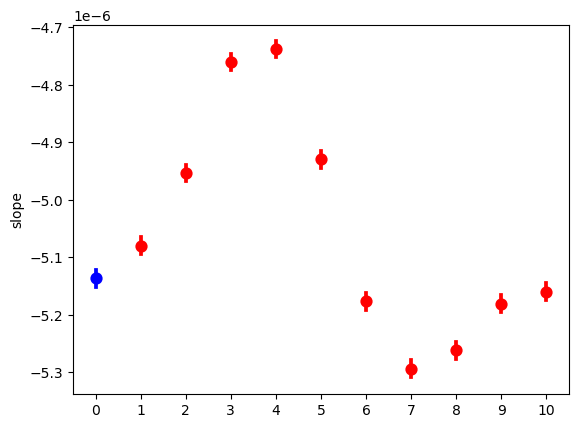

In [20]:
# Box plot of the average slope of b over each replicate for each simulation, 
fig, ax = plt.subplots()
sns.pointplot(data=pd.DataFrame(no_improvement_df['slope'].unique(), columns=['slope']), x=0, y='slope', ax=ax, color='blue', errorbar='se')
for i, improvement_df in enumerate(improvement_dfs):
    sns.pointplot(data=pd.DataFrame(improvement_df['slope'].unique(), columns=['slope']), x=i+1, y='slope', ax=ax, color='red', errorbar='se')

# extract the time improvement is active from file name, it's after fertility_ and before _random
time_improvement_active = [f.split("fertility_")[1].split("_random")[0] for f in improvement_csvs]
print(time_improvement_active)

plt.show()